<a href="https://colab.research.google.com/github/lucid005/AI-and-Machine-Learning/blob/main/Worksheet6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Dense, Flatten, Dropout, BatchNormalization, Activation
from tensorflow.keras.applications import VGG16
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import classification_report

TASK 1 — Load Dataset (FruitInAmazon)

In [ ]:
train_dir = "/content/drive/MyDrive/FruitinAmazon/train"

In [ ]:
class_names = sorted(os.listdir(train_dir))
print("Classes:", class_names)
print("Total classes:", len(class_names))

Classes: ['acai', 'cupuacu', 'graviola', 'guarana', 'pupunha', 'tucuma']
Total classes: 6


TASK 2 — Corrupted Image Check

In [ ]:
from PIL import Image, UnidentifiedImageError

corrupted = []

for c in class_names:
    path = os.path.join(train_dir, c)
    for img in os.listdir(path):
        img_path = os.path.join(path, img)
        try:
            Image.open(img_path).verify()
        except:
            corrupted.append(img_path)

print("Corrupted images:", len(corrupted))

Corrupted images: 0


TASK 3 — Class Distribution

In [ ]:
class_counts = {}

for c in class_names:
    path = os.path.join(train_dir, c)
    class_counts[c] = len(os.listdir(path))

print(class_counts)

{'acai': 15, 'cupuacu': 15, 'graviola': 15, 'guarana': 15, 'pupunha': 15, 'tucuma': 15}


Plot Distribution

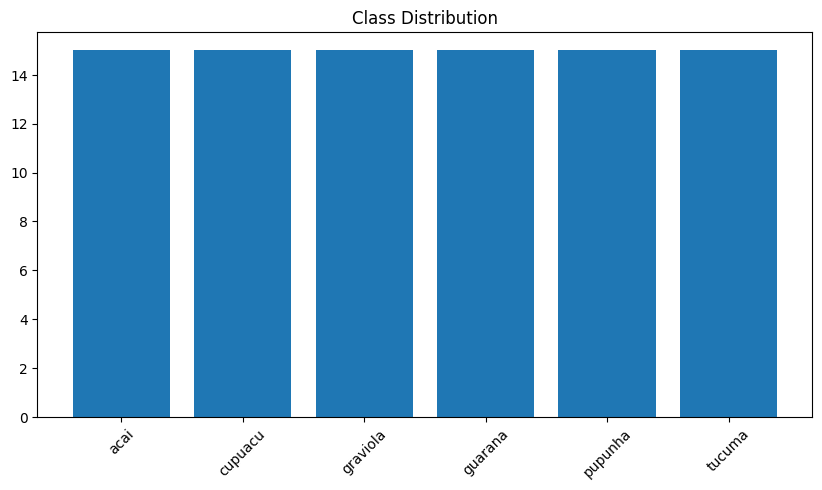

In [ ]:
plt.figure(figsize=(10,5))
plt.bar(class_counts.keys(), class_counts.values())
plt.xticks(rotation=45)
plt.title("Class Distribution")
plt.show()

TASK 4 — Load Dataset (Train + Validation Split)

In [ ]:
img_size = (224, 224)
batch_size = 32

train_ds = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=img_size,
    batch_size=batch_size
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=img_size,
    batch_size=batch_size
)

Found 90 files belonging to 6 classes.
Using 72 files for training.
Found 90 files belonging to 6 classes.
Using 18 files for validation.


TASK 5 — Data Augmentation

In [ ]:
data_aug = Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
])

Visualize Augmentation

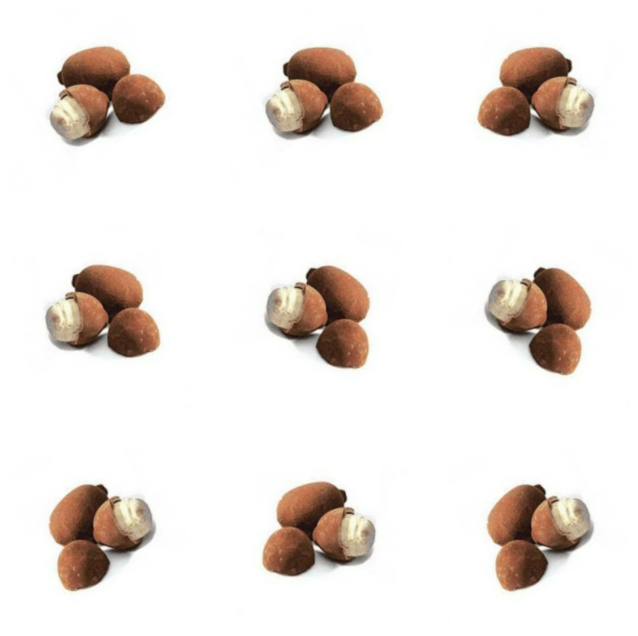

In [ ]:
for images, labels in train_ds.take(1):
    plt.figure(figsize=(8,8))
    for i in range(9):
        aug_img = data_aug(images)
        ax = plt.subplot(3,3,i+1)
        plt.imshow(aug_img[0].numpy().astype("uint8"))
        plt.axis("off")
    plt.show()

TASK 6 — Preprocessing (Scaling)

In [ ]:
normalization = layers.Rescaling(1./255)

model = Sequential([
    layers.Input(shape=(224,224,3)),
    normalization,   # 👈 ADD THIS FIRST

    # rest of your model...
])

In [ ]:
for images, labels in train_ds.take(1):
    out = normalization(images)
    print(out.numpy().min(), out.numpy().max())

0.0 1.0


TASK 7 — CNN MODEL (FROM SCRATCH + BN + DROPOUT)

In [ ]:
model = Sequential([

    layers.Input(shape=(224,224,3)),

    data_aug,
    normalization,

    Conv2D(32, 3, padding='same', activation=None),
    BatchNormalization(),
    Activation('relu'),
    MaxPooling2D(),
    Dropout(0.25),

    Conv2D(64, 3, padding='same', activation=None),
    BatchNormalization(),
    Activation('relu'),
    MaxPooling2D(),
    Dropout(0.25),

    Conv2D(128, 3, padding='same', activation=None),
    BatchNormalization(),
    Activation('relu'),
    MaxPooling2D(),
    Dropout(0.25),

    Flatten(),

    Dense(256, activation=None),
    BatchNormalization(),
    Activation('relu'),
    Dropout(0.5),

    Dense(len(class_names), activation='softmax')
])

Compile Model

In [ ]:
model.compile(
    optimizer=Adam(),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_1 (Rescaling)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_4 (Activation)       │ (None, 224, 224, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_5 (Activation)       │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_6 (Activation)       │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 100352)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 256)            │    25,690,368 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_7 (Activation)       │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 6)              │         1,54

 Total params: 25,787,078 (98.37 MB)

 Trainable params: 25,786,118 (98.37 MB)

 Non-trainable params: 960 (3.75 KB)

Train Model (Scratch CNN)

In [ ]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10
)

Epoch 1/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 21s 4s/step - accuracy: 0.1806 - loss: 2.6135 - val_accuracy: 0.2222 - val_loss: 2.3589
Epoch 2/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 15s 4s/step - accuracy: 0.5694 - loss: 1.3318 - val_accuracy: 0.3333 - val_loss: 1.8654
Epoch 3/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 15s 4s/step - accuracy: 0.6389 - loss: 1.0252 - val_accuracy: 0.2778 - val_loss: 2.0237
Epoch 4/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 15s 4s/step - accuracy: 0.7222 - loss: 0.9640 - val_accuracy: 0.1111 - val_loss: 2.1872
Epoch 5/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 21s 4s/step - accuracy: 0.7361 - loss: 0.8160 - val_accuracy: 0.1111 - val_loss: 2.5284
Epoch 6/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 16s 4s/step - accuracy: 0.6111 - loss: 0.9699 - val_accuracy: 0.1111 - val_loss: 2.7769
Epoch 7/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 20s 5s/step - accuracy: 0.7361 - loss: 0.6771 - val_accuracy: 0.1111 - val_loss: 2.9586
Epoch 8/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 15s 5s/step - accuracy: 0.7778 - loss: 0.5773 - val_accuracy: 0.1111 - val_loss: 3.0407
Epoch 9/

Evaluate CNN

In [ ]:
model.evaluate(val_ds)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 640ms/step - accuracy: 0.1111 - loss: 3.1332


[3.133242607116699, 0.1111111119389534]

TASK 2 — TRANSFER LEARNING (VGG16)

Load VGG16

In [ ]:
base_model = VGG16(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)

Freeze Layers

In [ ]:
for layer in base_model.layers:
    layer.trainable = False

Add Custom Head

In [ ]:
x = base_model.output
x = layers.GlobalAveragePooling2D()(x)
x = Dense(512, activation='relu')(x)
x = Dropout(0.3)(x)
output = Dense(len(class_names), activation='softmax')(x)

transfer_model = Model(inputs=base_model.input, outputs=output)

Compile Transfer Model

In [ ]:
transfer_model.compile(
    optimizer=Adam(),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

Train Transfer Model

In [ ]:
history2 = transfer_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=5
)

Epoch 1/5
3/3 ━━━━━━━━━━━━━━━━━━━━ 52s 17s/step - accuracy: 0.2500 - loss: 8.0606 - val_accuracy: 0.5556 - val_loss: 2.5777
Epoch 2/5
3/3 ━━━━━━━━━━━━━━━━━━━━ 50s 16s/step - accuracy: 0.5556 - loss: 2.5568 - val_accuracy: 0.5000 - val_loss: 1.9538
Epoch 3/5
3/3 ━━━━━━━━━━━━━━━━━━━━ 82s 16s/step - accuracy: 0.7222 - loss: 1.4428 - val_accuracy: 0.6111 - val_loss: 2.1727
Epoch 4/5
3/3 ━━━━━━━━━━━━━━━━━━━━ 51s 17s/step - accuracy: 0.8611 - loss: 0.3821 - val_accuracy: 0.5556 - val_loss: 2.1914
Epoch 5/5
3/3 ━━━━━━━━━━━━━━━━━━━━ 80s 16s/step - accuracy: 0.9444 - loss: 0.2399 - val_accuracy: 0.7222 - val_loss: 2.3044


Evaluate Transfer Model

In [ ]:
transfer_model.evaluate(val_ds)

1/1 ━━━━━━━━━━━━━━━━━━━━ 11s 11s/step - accuracy: 0.7222 - loss: 2.3044


[2.304443359375, 0.7222222089767456]

TASK 3 — PREDICTION + CLASSIFICATION REPORT

Get predictions

In [ ]:
y_true = []
y_pred = []

for images, labels in val_ds:
    preds = transfer_model.predict(images)
    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(preds, axis=1))

1/1 ━━━━━━━━━━━━━━━━━━━━ 9s 9s/step


Classification Report

In [ ]:
print(classification_report(y_true, y_pred, target_names=class_names))

              precision    recall  f1-score   support

        acai       1.00      1.00      1.00         1
     cupuacu       0.50      0.50      0.50         2
    graviola       1.00      1.00      1.00         3
     guarana       0.67      0.80      0.73         5
     pupunha       0.67      0.50      0.57         4
      tucuma       0.67      0.67      0.67         3

    accuracy                           0.72        18
   macro avg       0.75      0.74      0.74        18
weighted avg       0.72      0.72      0.72        18

